# Step 1: Data Understanding, Analysis, Visualization and Cleaning

 The dataset is sourced from the International Skin Imaging Collaboration (ISIC) and is publicly available on Kaggle under the title "Skin Cancer 9 Classes ISIC" https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
The dataset is pre-organised into two top-level folders:
•	Train - contains labelled training images organised into subfolders per class.
•	Test – contains unlabelled images for model inference and evaluation.
Each class subfolder within the Train directory contains dermoscopic images in standard image formats (jpg/png).

The dataset contains nine classes of skin lesions:
•	Actinic Keratosis
•	Basal Cell Carcinoma
•	Dermatofibroma
•	Melanoma
•	Nevus
•	Pigmented Benign Keratosis
•	Seborrheic Keratosis
•	Squamous Cell Carcinoma
•	Vascular Lesion



In [ ]:

train_dir = '/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train'
test_dir = '/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Test'
import os
class_names = sorted(os.listdir(train_dir))
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 9 classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [ ]:
  # import PIL, PIL.Image
  # from PIL import UnidentifiedImageError
  # from PIL import Image
  # corrupted_images = []
  # for class_name in class_names:
  #     class_path = os.path.join(train_dir, class_name)
  #     if os.path.isdir(class_path):
  #         images = os.listdir(class_path)
  #         for img_name in images:
  #             img_path = os.path.join(class_path, img_name)
  #             try:
  #                 with Image.open(img_path) as img:
  #                     img.verify()
  #             except (IOError, UnidentifiedImageError):
  #                 corrupted_images.append(img_path)

  # if corrupted_images:
  #     print("\nCorrupted Images Found:")
  #     for img in corrupted_images:
  #         print(img)
  # else:
  #     print("\nNo corrupted images found.")

import os
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    img.load()
            except (IOError, UnidentifiedImageError, Exception) as e:
                corrupted_images.append((img_path, str(e)))
if corrupted_images:
    print(f"\nCorrupted images found: {len(corrupted_images)}")
    for img_path, error in corrupted_images:
        print(f"{img_path}")
else:
    print(f"\nNo corrupted images found.")


Corrupted images found: 63
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0029460.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0027958.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0030730.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0025957.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0028076.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/ISIC_0026171.jpg
/content/drive/MyDrive/Skin Cancer Classification-20260421T141135Z-3-001/Skin Cancer Classification/Train/actinic keratosis/IS

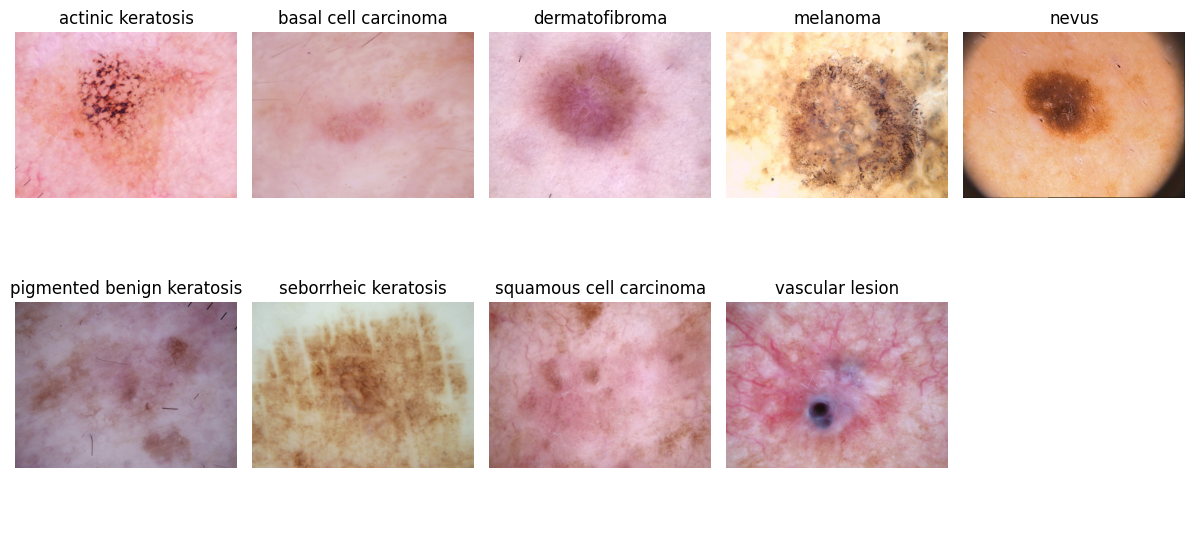

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
selected_images = []
selected_labels = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
def count_images(folder_path):
    """Count images in each class folder."""
    class_counts = {}
    for class_name in sorted(os.listdir(folder_path)):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            num_images = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            class_counts[class_name] = num_images
    return class_counts

# Count
train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)

# DataFrame summary
df = pd.DataFrame({
    "Train": train_counts,
    "Test":  test_counts
}).fillna(0).astype(int)
df["Total"] = df["Train"] + df["Test"]
df = df.sort_values("Total", ascending=False)
print(df)
print(f"Total train images: {df['Train'].sum()}")
print(f"Total test images: {df['Test'].sum()}")


                            Train  Test  Total
pigmented benign keratosis    462    16    478
melanoma                      438    16    454
basal cell carcinoma          376    16    392
nevus                         357    16    373
squamous cell carcinoma       181    16    197
vascular lesion               148     3    151
actinic keratosis             114    16    130
dermatofibroma                 95    16    111
seborrheic keratosis           77     3     80
Total train images: 2248
Total test images: 118


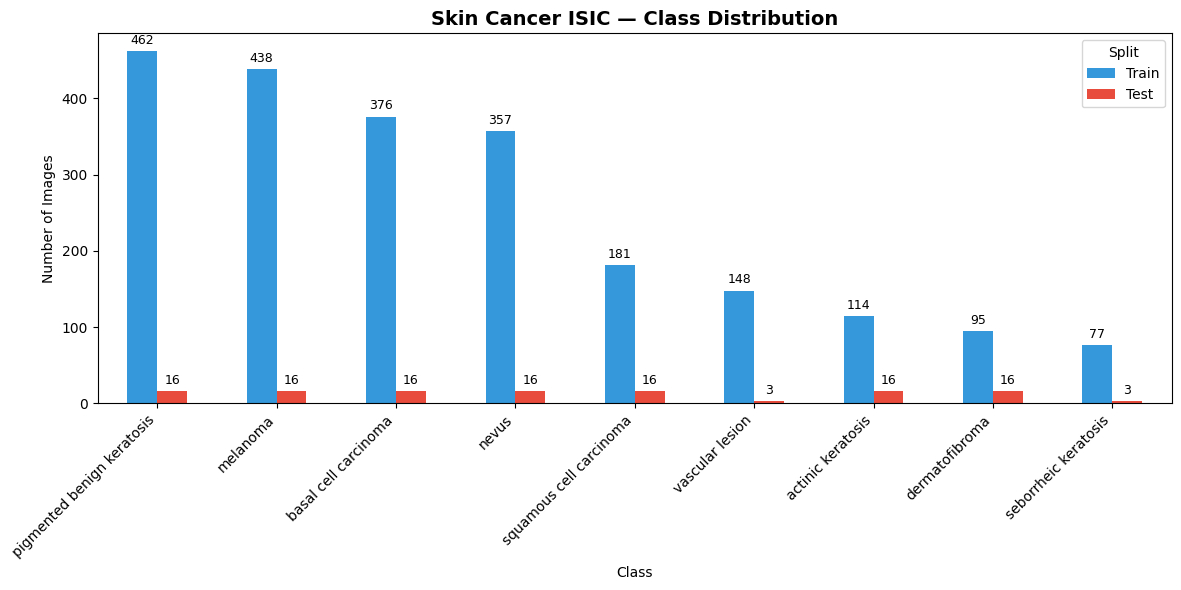

In [ ]:
# Bar chart — Train vs Test
fig, ax = plt.subplots(figsize=(12, 6))
df[["Train", "Test"]].plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Skin Cancer ISIC — Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.legend(title="Split")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Based on the dataset structure from ISIC, the class distribution is significantly imbalanced. Nevus and melanoma classes typically contain the most samples, while classes such as dermatofibroma, actinic keratosis, and vascular lesion contain considerably fewer images. This imbalance is a known characteristic of real-world dermatological data and must be addressed during preprocessing. Planned mitigation strategies include class-weighted loss functions, data augmentation on minority classes, and oversampling techniques where appropriate

In [ ]:
import numpy as np
widths, heights = [], []
unreadable = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        img.load()
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                except Exception:
                    unreadable.append(img_path)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"All same size: {len(set(zip(widths, heights))) == 1}")
print(f"\nUnreadable files found: {len(unreadable)}")

Width  — min: 576, max: 3872, mean: 864
Height — min: 450, max: 2592, mean: 652
All same size: False

Unreadable files found: 63


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

In [ ]:
# train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dir,
#     validation_split=0.2,
#     subset="both",
#     seed=SEED,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode='categorical'
# )

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     test_dir,
#     seed=SEED,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode='categorical',
#     shuffle=False
# )
# class_names = train_ds.class_names
# num_classes = len(class_names)
# print(f"Classes ({num_classes}): {class_names}")

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
num_classes  = len(class_names)

# capture BEFORE pipeline applies .repeat()
steps_per_epoch  = tf.data.experimental.cardinality(train_ds).numpy()
validation_steps = tf.data.experimental.cardinality(val_ds).numpy()

print(f"Classes ({num_classes})  : {class_names}")
print(f"Steps per epoch          : {steps_per_epoch}")
print(f"Validation steps         : {validation_steps}")

Found 2248 files belonging to 9 classes.
Using 1799 files for training.
Using 449 files for validation.
Found 118 files belonging to 9 classes.
Classes (9)  : ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Steps per epoch          : 57
Validation steps         : 15


In [ ]:
# Augmentations for majority and minority classes
mild_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
], name="mild_augmentation")

strong_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
], name="strong_augmentation")

In [ ]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name] = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

avg_count = np.mean(list(class_counts.values()))

minority_indices = tf.constant(
    [class_names.index(c) for c, count in class_counts.items()
     if count < avg_count],
    dtype=tf.int32
)

print(f"Average count: {avg_count:.0f}")
print("\nMinority classes (strong augmentation):")
for c, count in class_counts.items():
    if count < avg_count:
        print(f"  {c:35s}: {count}")

print("\nMajority classes (mild augmentation):")
for c, count in class_counts.items():
    if count >= avg_count:
        print(f"  {c:35s}: {count}")

Average count: 250

Minority classes (strong augmentation):
  actinic keratosis                  : 114
  dermatofibroma                     : 95
  seborrheic keratosis               : 77
  squamous cell carcinoma            : 181
  vascular lesion                    : 148

Majority classes (mild augmentation):
  basal cell carcinoma               : 376
  melanoma                           : 438
  nevus                              : 357
  pigmented benign keratosis         : 462


In [ ]:
def adaptive_augment(images, labels):
    """
    Apply strong augmentation to minority classes,
    mild augmentation to majority classes.
    """
    class_indices = tf.argmax(labels, axis=1)

    # Check minority membership per image
    is_minority = tf.reduce_any(
        tf.equal(
            tf.cast(tf.expand_dims(class_indices, 1), tf.int32),
            tf.expand_dims(minority_indices, 0)
        ),
        axis=1
    )

    # Apply both augmentations
    strongly_augmented = strong_augmentation(images, training=True)
    mildly_augmented   = mild_augmentation(images, training=True)

    # Select per image: strong if minority, mild if majority
    result = tf.where(
        tf.reshape(is_minority, [-1, 1, 1, 1]),
        strongly_augmented,
        mildly_augmented
    )
    return result, labels

In [ ]:
# # # APPLY TO PIPELINE
# # AUTOTUNE = tf.data.AUTOTUNE

# # train_ds = (train_ds
# #     .apply(tf.data.experimental.ignore_errors())
# #     .cache()
# #     .map(adaptive_augment, num_parallel_calls=AUTOTUNE)
# #     .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)

# #     .repeat()        #keeps dataset cycling through epochs

# #     .shuffle(1000, seed=SEED)
# #     .prefetch(AUTOTUNE)
# # )

# # val_ds = (val_ds
# #     .apply(tf.data.experimental.ignore_errors())
# #     .map(lambda x, y: (x / 255.0, y),
# #          num_parallel_calls=AUTOTUNE)
# #     .cache()
# #     .prefetch(AUTOTUNE)
# # )

# # test_ds = (test_ds
# #     .apply(tf.data.experimental.ignore_errors())
# #     .map(lambda x, y: (x / 255.0, y),
# #          num_parallel_calls=AUTOTUNE)
# #     .cache()
# #     .prefetch(AUTOTUNE)
# # )
# # then apply pipeline fresh




# AUTOTUNE = tf.data.AUTOTUNE

# train_ds = (train_ds
#     .apply(tf.data.experimental.ignore_errors())
#     .cache()
#     .map(adaptive_augment, num_parallel_calls=AUTOTUNE)
#     .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
#     .repeat()
#     .shuffle(1000, seed=SEED)
#     .prefetch(AUTOTUNE)
# )

# val_ds = (val_ds
#     .apply(tf.data.experimental.ignore_errors())
#     .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
#     .cache()
#     .repeat()
#     .prefetch(AUTOTUNE)
# )

# test_ds = (test_ds
#     .apply(tf.data.experimental.ignore_errors())
#     .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
#     .cache()
#     .prefetch(AUTOTUNE)
# )

AUTOTUNE = tf.data.AUTOTUNE

# Save reference for evaluation
raw_val_ds = val_ds

# Training pipeline
train_ds = (train_ds
    .apply(tf.data.experimental.ignore_errors())
    .cache()
    .shuffle(1000, seed=SEED)
    .repeat()
    .map(adaptive_augment, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Validation pipeline (used during fit, needs repeat)
val_ds = (val_ds
    .apply(tf.data.experimental.ignore_errors())
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .cache()
    .repeat()
    .prefetch(AUTOTUNE)
)

# test_ds now points to validation split (no .repeat() for clean evaluation)
test_ds = (raw_val_ds
    .apply(tf.data.experimental.ignore_errors())
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Pipeline ready.")
print(f"  steps_per_epoch  : {steps_per_epoch}")
print(f"  validation_steps : {validation_steps}")


Pipeline ready.
  steps_per_epoch  : 57
  validation_steps : 15


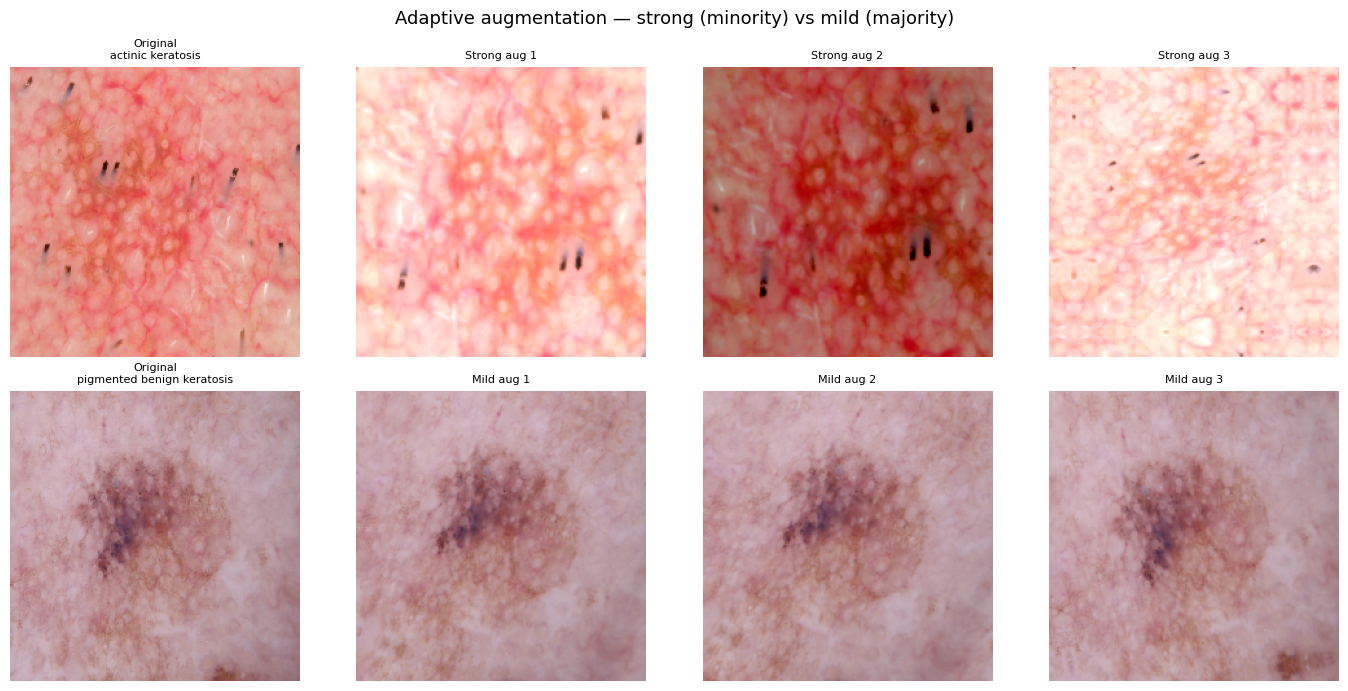

In [ ]:
# VISUALIZE BOTH AUGMENTATION LEVELS
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Adaptive augmentation — strong (minority) vs mild (majority)",
             fontsize=13)

# Pick one minority and one majority class example
minority_class = [c for c, count in class_counts.items()
                  if count < avg_count][0]
majority_class = max(class_counts, key=class_counts.get)

def load_first_image(class_name):
    folder = os.path.join(train_dir, class_name)
    fname  = os.listdir(folder)[0]
    img    = tf.keras.preprocessing.image.load_img(
                 os.path.join(folder, fname), target_size=IMG_SIZE)
    arr    = tf.keras.preprocessing.image.img_to_array(img)
    return arr

min_img = load_first_image(minority_class)
maj_img = load_first_image(majority_class)

# Row 1 — minority with STRONG augmentation
axes[0][0].imshow(min_img.astype("uint8"))
axes[0][0].set_title(f"Original\n{minority_class}", fontsize=8)
axes[0][0].axis("off")

for i in range(1, 4):
    aug = strong_augmentation(
        tf.expand_dims(min_img, 0), training=True)
    axes[0][i].imshow(aug[0].numpy().astype("uint8"))
    axes[0][i].set_title(f"Strong aug {i}", fontsize=8)
    axes[0][i].axis("off")

# Row 2 — majority with MILD augmentation
axes[1][0].imshow(maj_img.astype("uint8"))
axes[1][0].set_title(f"Original\n{majority_class}", fontsize=8)
axes[1][0].axis("off")

for i in range(1, 4):
    aug = mild_augmentation(
        tf.expand_dims(maj_img, 0), training=True)
    axes[1][i].imshow(aug[0].numpy().astype("uint8"))
    axes[1][i].set_title(f"Mild aug {i}", fontsize=8)
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("adaptive_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 2: Implementing a baseline CNN model architecture with 3 convolution layers

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    # Convolution Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Convolution Layer 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(9, activation='softmax') # for multi-class classification
])

baseline_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name ="precision"),
                       tf.keras.metrics.Recall(name = "recall")])
# Model summary
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,409 (85.02 MB)

 Trainable params: 22,286,409 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

#Implementing a weighted class concept

In [ ]:
# # Model Training and Class weight
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# callbacks_baseline = [
#     EarlyStopping(
#         monitor='val_loss',
#         patience=5,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     ModelCheckpoint(
#         'baseline_best.keras',
#         monitor='val_loss',
#         save_best_only=True,
#         verbose=1
#     )
# ]

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

labels_list = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    labels_list.extend([class_names.index(class_name)] * count)

labels_array  = np.array(labels_list)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {class_weight_dict[i]:.3f}")

Class weights:
  actinic keratosis                  : 2.191
  basal cell carcinoma               : 0.664
  dermatofibroma                     : 2.629
  melanoma                           : 0.570
  nevus                              : 0.700
  pigmented benign keratosis         : 0.541
  seborrheic keratosis               : 3.244
  squamous cell carcinoma            : 1.380
  vascular lesion                    : 1.688


In [ ]:
# # calculate steps per epoch
# import math

# train_size = sum([
#     len([f for f in os.listdir(os.path.join(train_dir, c))
#          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
#     for c in class_names
# ])

# steps_per_epoch  = math.ceil(train_size * 0.8 / BATCH_SIZE)
# validation_steps = math.ceil(train_size * 0.2 / BATCH_SIZE)

# print(f"total training images:   {train_size}")
# print(f"steps per epoch:         {steps_per_epoch}")
# print(f"validation steps:        {validation_steps}")

# Model Training for Baseline CNN


In [ ]:
# Train
import time
from tensorflow.keras.callbacks import EarlyStopping
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,  # restores weights from best epoch
            verbose=1
        )
    ]
)

baseline_training_time = time.time() - start_time
print(f"training time: {baseline_training_time/60:.2f} minutes")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.1933 - loss: 2.1399 - precision: 0.1143 - recall: 0.0023 - val_accuracy: 0.2895 - val_loss: 2.1093 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.2570 - loss: 1.9003 - precision: 0.5385 - recall: 0.0203 - val_accuracy: 0.2717 - val_loss: 1.7052 - val_precision: 0.4167 - val_recall: 0.0668
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.2870 - loss: 1.7140 - precision: 0.5387 - recall: 0.0835 - val_accuracy: 0.2962 - val_loss: 1.7474 - val_precision: 0.6327 - val_recall: 0.1381
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.3145 - loss: 1.6580 - precision: 0.6065 - recall: 0.1075 - val_accuracy: 0.2695 - val_loss: 1.8156 - val_precision: 0.6552 - val_recall: 0.0846
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.3591 - loss: 1.5484 - precision: 0.5687 - recall: 0.1206 - val_accuracy: 0.3252 - val_los

# training vs validation loss and accuracy curves

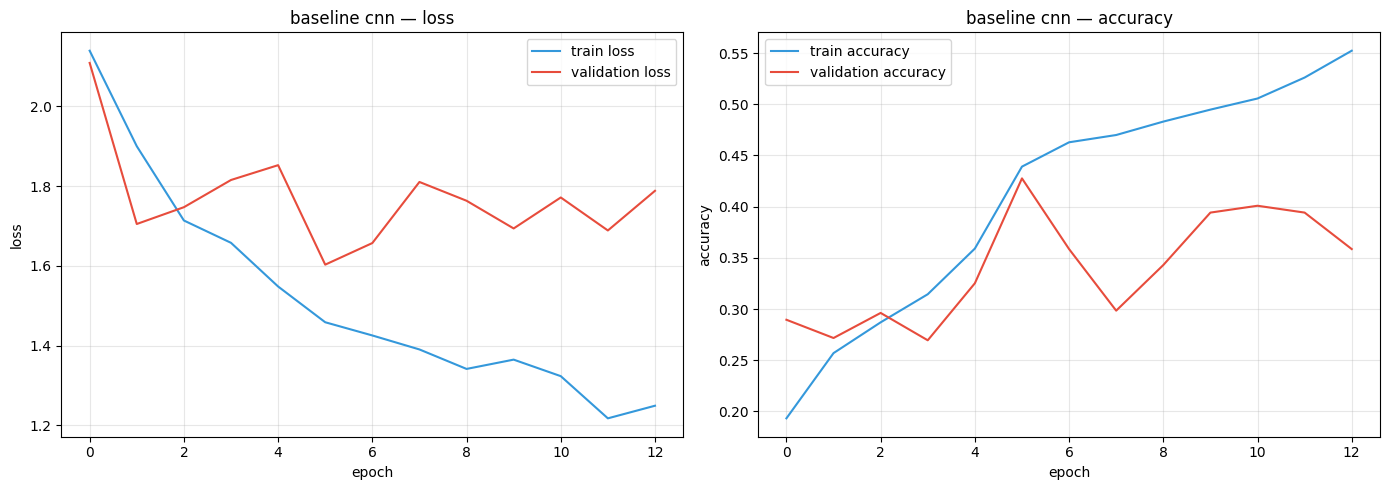

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['loss'],     label='train loss',      color='#3498db')
axes[0].plot(history_baseline.history['val_loss'], label='validation loss', color='#e74c3c')
axes[0].set_title('baseline cnn — loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['accuracy'],     label='train accuracy',      color='#3498db')
axes[1].plot(history_baseline.history['val_accuracy'], label='validation accuracy', color='#e74c3c')
axes[1].set_title('baseline cnn — accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# evaluate using accuracy, precision, recall, f1

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = np.argmax(baseline_model.predict(test_ds), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

print(classification_report(y_true, y_pred, target_names=class_names,zero_division=0))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        10
      basal cell carcinoma       0.44      0.40      0.42        35
            dermatofibroma       0.15      0.18      0.17        11
                  melanoma       0.52      0.22      0.31        50
                     nevus       0.94      0.38      0.54        45
pigmented benign keratosis       0.43      0.76      0.55        59
      seborrheic keratosis       0.15      0.86      0.26         7
   squamous cell carcinoma       0.15      0.09      0.11        23
           vascular lesion       0.88      0.82      0.85        17

                  accuracy                           0.43       257
                 macro avg       0.41      0.41      0.36       257
              weighted avg       0.51      0.43      0.42       257



# Confusion matrix for basline CNN model

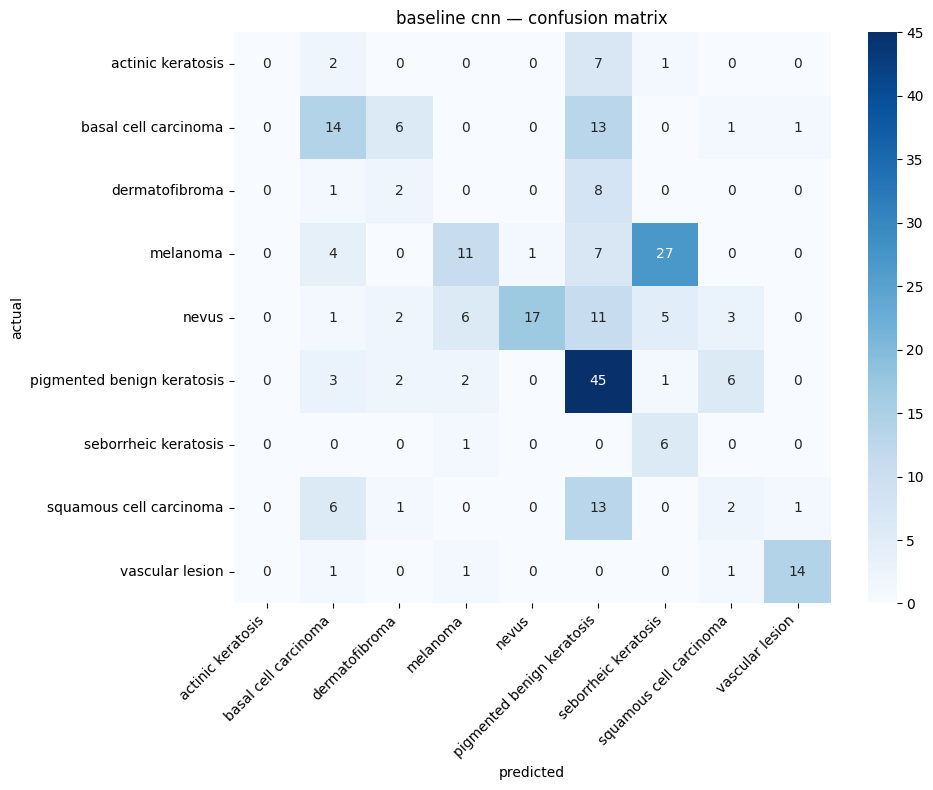

In [ ]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('baseline cnn — confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Inference on sample images froim test set

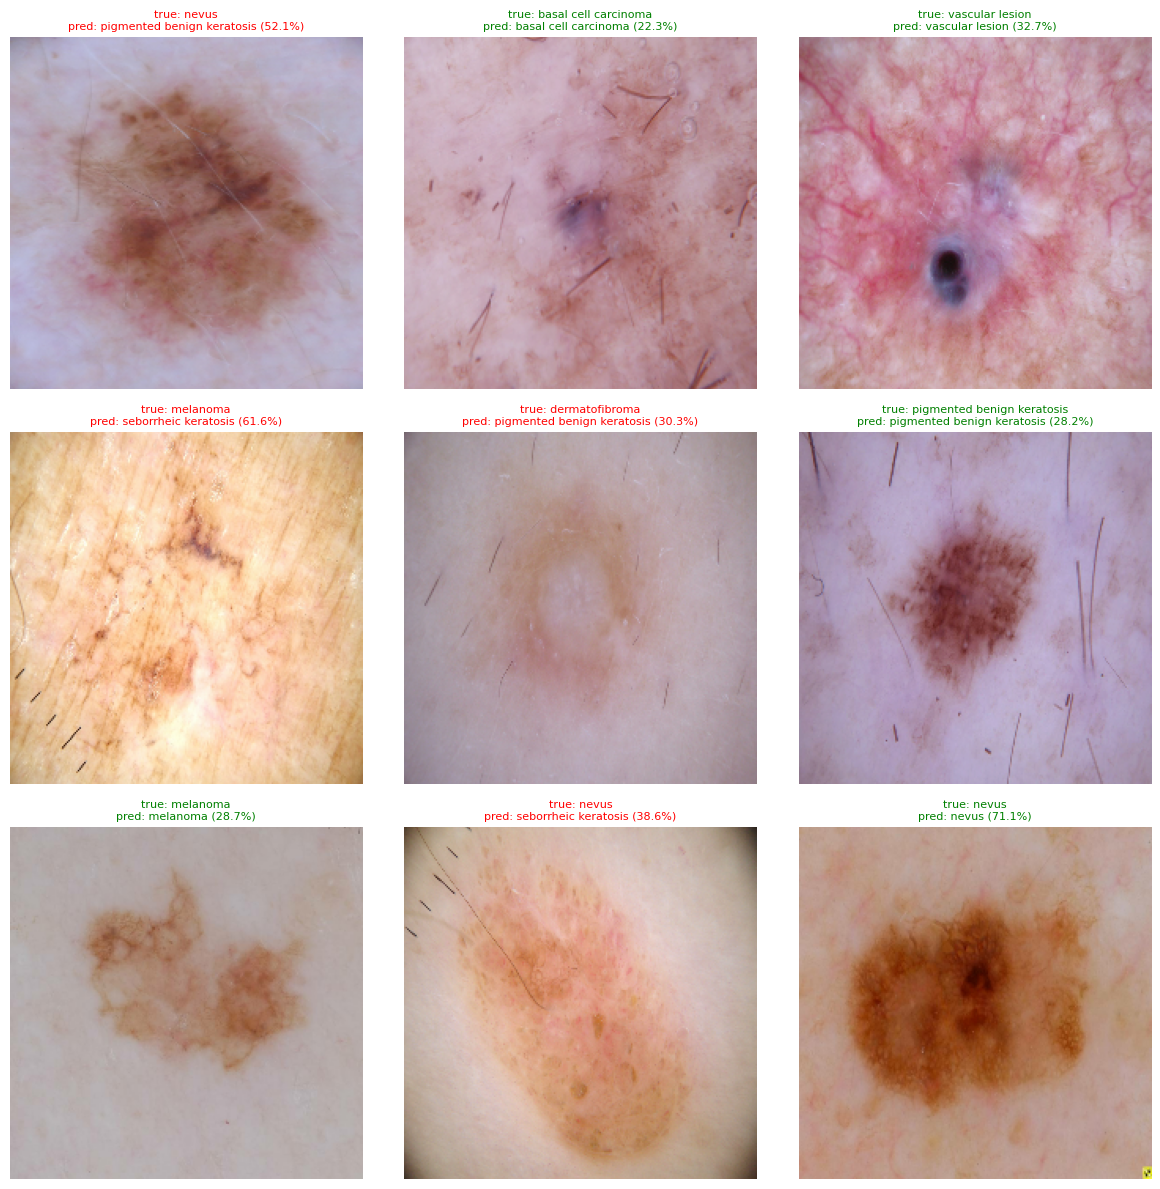

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

sample_images, sample_labels = next(iter(test_ds))
sample_np   = sample_images.numpy()
true_labels = np.argmax(sample_labels.numpy(), axis=1)
predictions = baseline_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

for i, ax in enumerate(axes.flat):
    img        = (sample_np[i] * 255).astype("uint8")
    true_name  = class_names[true_labels[i]]
    pred_name  = class_names[pred_labels[i]]
    confidence = predictions[i][pred_labels[i]] * 100

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"true: {true_name}\npred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color='green' if true_name == pred_name else 'red'
    )

plt.tight_layout()
plt.savefig('baseline_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.5.3 Deeper Architecture with Regularization Layer:

In [ ]:
# deeper_model = models.Sequential([

#     # conv block 1
#     layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),

#     # conv block 2
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),

#     # conv block 3
#     layers.Conv2D(128, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),

#     # conv block 4
#     layers.Conv2D(256, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),

#     # conv block 5
#     layers.Conv2D(512, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),

#     # conv block 6
#     layers.Conv2D(512, (3, 3), activation='relu'),
#     layers.BatchNormalization(),

#     # fully connected layers
#       layers.GlobalAveragePooling2D(),
#     layers.Dense(512, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.2),
#     layers.Dense(128, activation='relu'),

#     # output
#     layers.Dense(num_classes, activation='softmax')

# ], name="deeper_cnn")

# deeper_model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy',
#              tf.keras.metrics.Precision(name='precision'),
#              tf.keras.metrics.Recall(name='recall')]
# )

# deeper_model.summary()

deeper_model = models.Sequential([

    # conv block 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # conv block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # conv block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # conv block 4
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # conv block 5
    layers.Conv2D(512, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # conv block 6
    layers.Conv2D(512, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # fully connected
    layers.GlobalAveragePooling2D(),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    # output
    layers.Dense(num_classes, activation='softmax')

], name="deeper_cnn")

deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,333,769 (16.53 MB)

 Trainable params: 4,329,225 (16.51 MB)

 Non-trainable params: 4,544 (17.75 KB)

# Deeper model training

In [ ]:
# # train deeper model
# from tensorflow.keras.callbacks import EarlyStopping

# start_time = time.time()

# history_deeper = deeper_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     class_weight=class_weight_dict,
#     callbacks=[
#         EarlyStopping(monitor='val_loss', patience=7,
#                       restore_best_weights=True, verbose=1)
#     ]
# )

# deeper_training_time = time.time() - start_time
# print(f"deeper model training time: {deeper_training_time/60:.2f} minutes")
# print(f"epochs completed: {len(history_deeper.history['loss'])}")


from tensorflow.keras.callbacks import EarlyStopping

start_time = time.time()

history_deeper = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=1)
    ]
)

deeper_training_time = time.time() - start_time
print(f"deeper model training time: {deeper_training_time/60:.2f} minutes")
print(f"epochs completed: {len(history_deeper.history['loss'])}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 363ms/step - accuracy: 0.2247 - loss: 2.2298 - precision: 0.2926 - recall: 0.0726 - val_accuracy: 0.1314 - val_loss: 2.7751 - val_precision: 0.1086 - val_recall: 0.0757
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.2981 - loss: 1.8873 - precision: 0.3950 - recall: 0.1276 - val_accuracy: 0.1314 - val_loss: 3.2663 - val_precision: 0.1314 - val_recall: 0.1314
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3439 - loss: 1.8349 - precision: 0.4415 - recall: 0.1618 - val_accuracy: 0.1314 - val_loss: 3.1229 - val_precision: 0.1320 - val_recall: 0.1314
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.3730 - loss: 1.6494 - precision: 0.5007 - recall: 0.2059 - val_accuracy: 0.1314 - val_loss: 3.5602 - val_precision: 0.1314 - val_recall: 0.1314
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.3968 - loss: 1.6434 - precision: 0.4771 - recall: 0.1967 - val_accuracy: 0.1314 - val_loss: 3.804

# compare loss curves — baseline vs deeper

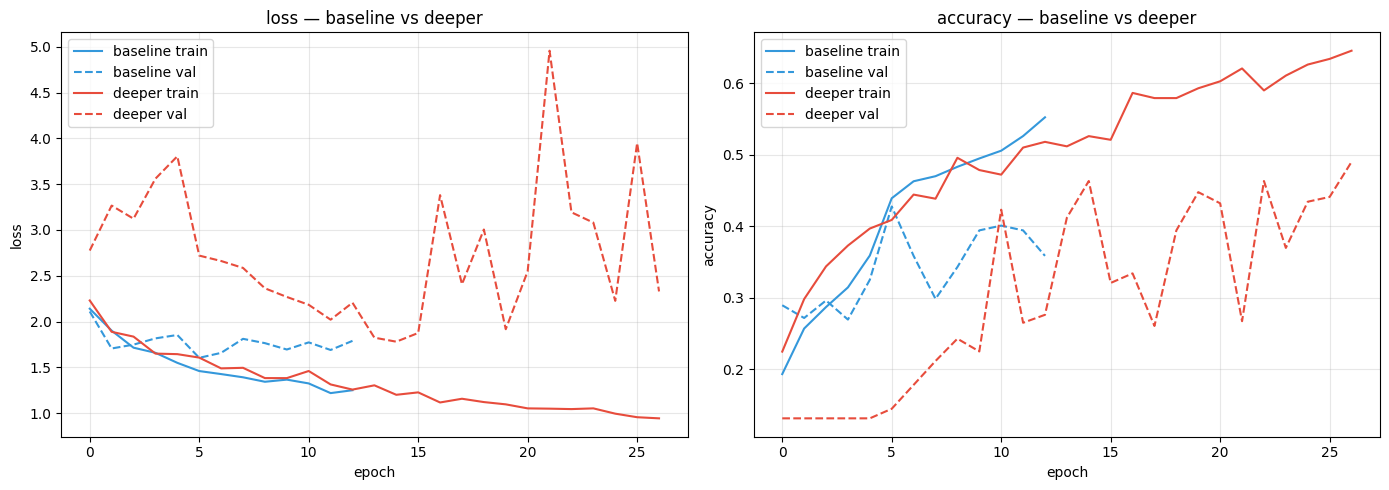

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss comparison
axes[0].plot(history_baseline.history['loss'],     label='baseline train',     color='#3498db')
axes[0].plot(history_baseline.history['val_loss'], label='baseline val',       color='#3498db', linestyle='--')
axes[0].plot(history_deeper.history['loss'],       label='deeper train',       color='#e74c3c')
axes[0].plot(history_deeper.history['val_loss'],   label='deeper val',         color='#e74c3c', linestyle='--')
axes[0].set_title('loss — baseline vs deeper')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy comparison
axes[1].plot(history_baseline.history['accuracy'],     label='baseline train', color='#3498db')
axes[1].plot(history_baseline.history['val_accuracy'], label='baseline val',   color='#3498db', linestyle='--')
axes[1].plot(history_deeper.history['accuracy'],       label='deeper train',   color='#e74c3c')
axes[1].plot(history_deeper.history['val_accuracy'],   label='deeper val',     color='#e74c3c', linestyle='--')
axes[1].set_title('accuracy — baseline vs deeper')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_vs_deeper_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation on  deeper model

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        10
      basal cell carcinoma       0.34      0.80      0.48        35
            dermatofibroma       0.00      0.00      0.00        11
                  melanoma       0.60      0.42      0.49        50
                     nevus       0.49      0.44      0.47        45
pigmented benign keratosis       0.53      0.69      0.60        59
      seborrheic keratosis       0.25      0.14      0.18         7
   squamous cell carcinoma       0.25      0.09      0.13        23
           vascular lesion       1.00      0.41      0.58        17

                  accuracy                           0.47       257
                 macro avg       0.38      0.33      0.33       257
              weighted avg       0.47      0.47      0.44       257



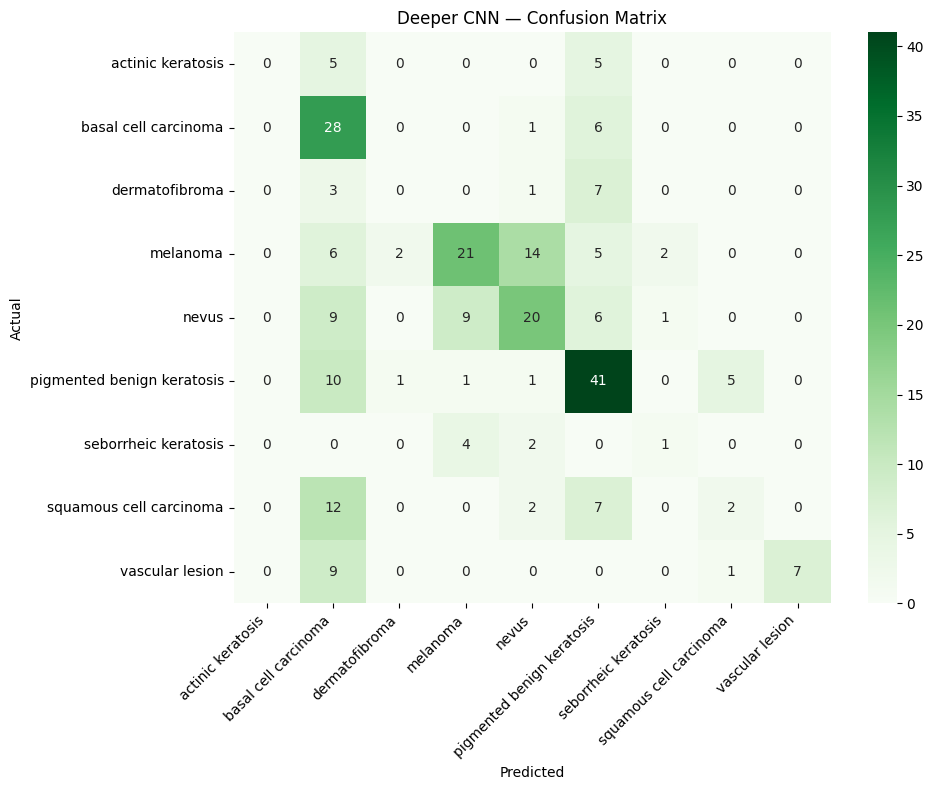

In [ ]:
#
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns

# y_pred_deeper = np.argmax(deeper_model.predict(test_ds), axis=1)
# y_true        = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

# print(classification_report(y_pred_deeper, y_true, target_names=class_names))

# cm = confusion_matrix(y_true, y_pred_deeper)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
#             xticklabels=class_names, yticklabels=class_names)
# plt.title('deeper cnn — confusion matrix')
# plt.xlabel('predicted')
# plt.ylabel('actual')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
# plt.show()


# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns

# y_pred_deeper = np.argmax(deeper_model.predict(test_ds), axis=1)
# y_true        = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

# # y_true first, y_pred second — order matters
# print(classification_report(y_true, y_pred_deeper, target_names=class_names, zero_division=0))

# cm = confusion_matrix(y_true, y_pred_deeper)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
#             xticklabels=class_names, yticklabels=class_names)
# plt.title('Deeper CNN — Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
# plt.show()



# evaluate deeper model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_deeper = np.argmax(deeper_model.predict(test_ds), axis=1)
y_true        = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

print(classification_report(y_true, y_pred_deeper, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred_deeper)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

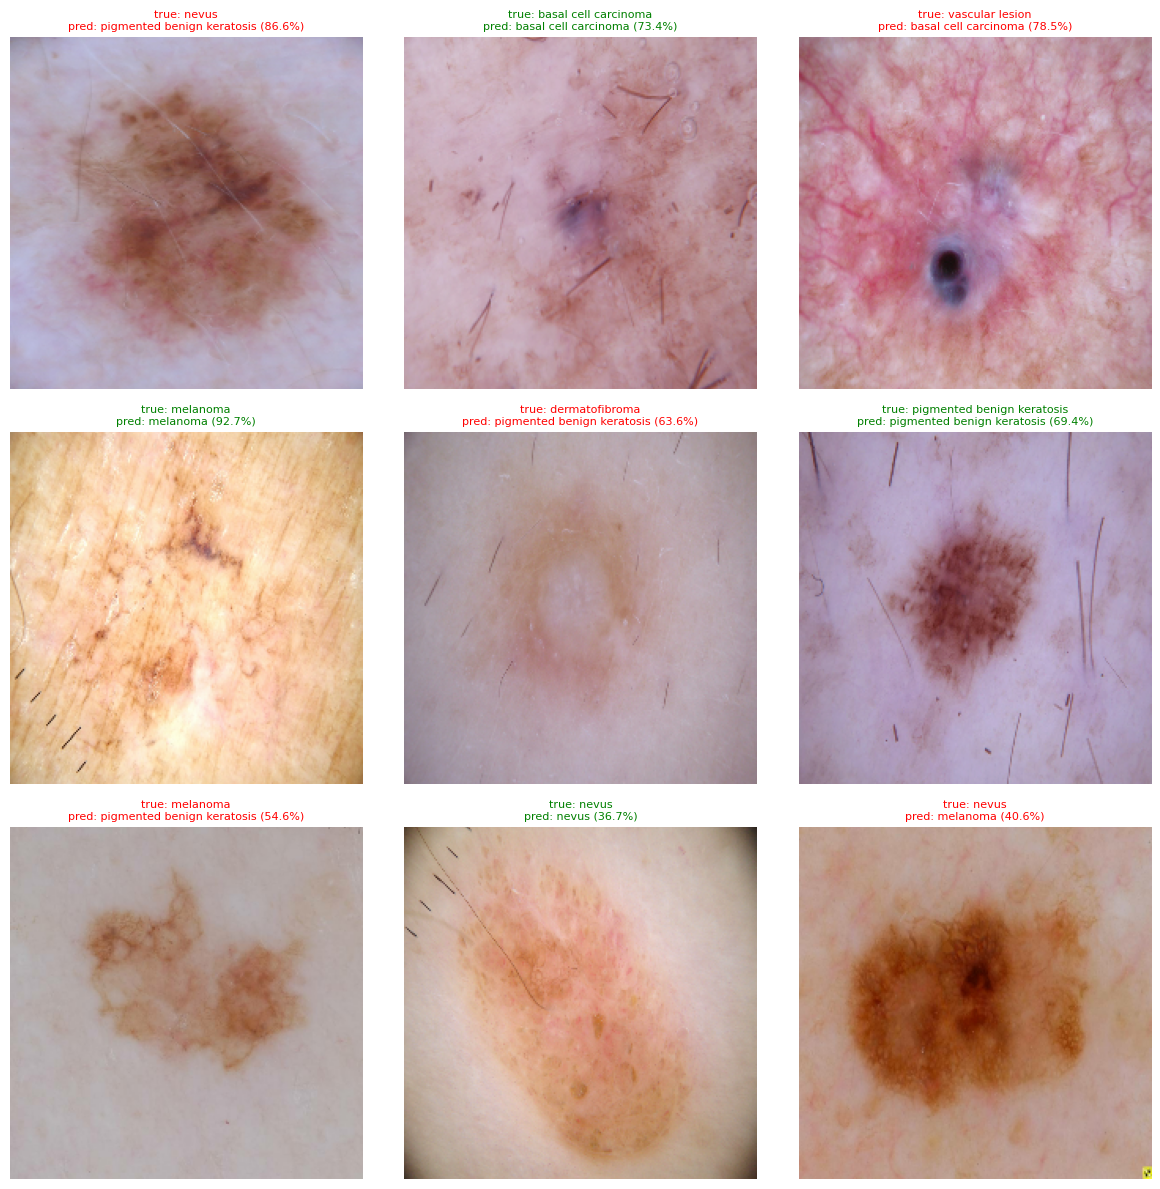

In [ ]:
# inference on sample images — deeper model
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

sample_images, sample_labels = next(iter(test_ds))
sample_np   = sample_images.numpy()
true_labels = np.argmax(sample_labels.numpy(), axis=1)
predictions = deeper_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

for i, ax in enumerate(axes.flat):
    img        = (sample_np[i] * 255).astype("uint8")
    true_name  = class_names[true_labels[i]]
    pred_name  = class_names[pred_labels[i]]
    confidence = predictions[i][pred_labels[i]] * 100

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"true: {true_name}\npred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color='green' if true_name == pred_name else 'red'
    )

plt.tight_layout()
plt.savefig('deeper_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.5.4 — baseline vs deeper performance comparison table

In [ ]:

test_loss_b, test_acc_b, test_prec_b, test_rec_b = baseline_model.evaluate(test_ds, verbose=0)
test_loss_d, test_acc_d, test_prec_d, test_rec_d = deeper_model.evaluate(test_ds, verbose=0)

f1_b = 2 * (test_prec_b * test_rec_b) / (test_prec_b + test_rec_b + 1e-7)
f1_d = 2 * (test_prec_d * test_rec_d) / (test_prec_d + test_rec_d + 1e-7)

comparison_df = pd.DataFrame({
    'metric':    ['accuracy', 'precision', 'recall', 'f1 score', 'training time (mins)'],
    'baseline':  [f"{test_acc_b:.4f}", f"{test_prec_b:.4f}", f"{test_rec_b:.4f}",
                  f"{f1_b:.4f}", f"{baseline_training_time/60:.2f}"],
    'deeper':    [f"{test_acc_d:.4f}", f"{test_prec_d:.4f}", f"{test_rec_d:.4f}",
                  f"{f1_d:.4f}", f"{deeper_training_time/60:.2f}"]
})

print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


              metric baseline deeper
            accuracy   0.4319 0.4669
           precision   0.4930 0.5060
              recall   0.1362 0.3307
            f1 score   0.2134 0.4000
training time (mins)     1.21   2.30


# optimizer analysis — train deeper model with sgd

In [ ]:
#
# deeper_model_sgd = models.Sequential([
#     layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(128, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(256, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(512, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(512, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.Flatten(),
#     layers.Dense(512, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(num_classes, activation='softmax')
# ], name="deeper_cnn_sgd")

# # compile with sgd
# deeper_model_sgd.compile(
#     optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
#     loss='categorical_crossentropy',
#     metrics=['accuracy',
#              tf.keras.metrics.Precision(name='precision'),
#              tf.keras.metrics.Recall(name='recall')]
# )

# start_time = time.time()

# history_sgd = deeper_model_sgd.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     class_weight=class_weight_dict,
#     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
#                              restore_best_weights=True, verbose=1)]
# )

# sgd_training_time = time.time() - start_time
# print(f"sgd training time: {sgd_training_time/60:.2f} minutes")

# optimizer analysis — deeper model with SGD
deeper_model_sgd = tf.keras.models.clone_model(deeper_model)

deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

start_time = time.time()

history_sgd = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

sgd_training_time = time.time() - start_time
print(f"SGD training time : {sgd_training_time/60:.2f} minutes")
print(f"Epochs completed  : {len(history_sgd.history['loss'])}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 240ms/step - accuracy: 0.2727 - loss: 2.2899 - precision: 0.3531 - recall: 0.0886 - val_accuracy: 0.0668 - val_loss: 20.0845 - val_precision: 0.0668 - val_recall: 0.0668
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3202 - loss: 2.1012 - precision: 0.3969 - recall: 0.1189 - val_accuracy: 0.0312 - val_loss: 3.6969 - val_precision: 0.0325 - val_recall: 0.0267
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.3373 - loss: 1.8891 - precision: 0.3975 - recall: 0.1264 - val_accuracy: 0.2918 - val_loss: 2.3164 - val_precision: 0.3510 - val_recall: 0.1626
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.3730 - loss: 1.7783 - precision: 0.4300 - recall: 0.1514 - val_accuracy: 0.2829 - val_loss: 2.1281 - val_precision: 0.4000 - val_recall: 0.1292
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3534 - loss: 1.6877 - precision: 0.4567 - recall: 0.1635 - val_accuracy: 0.2606 - val_loss: 2.13

# compare adam vs sgd curves

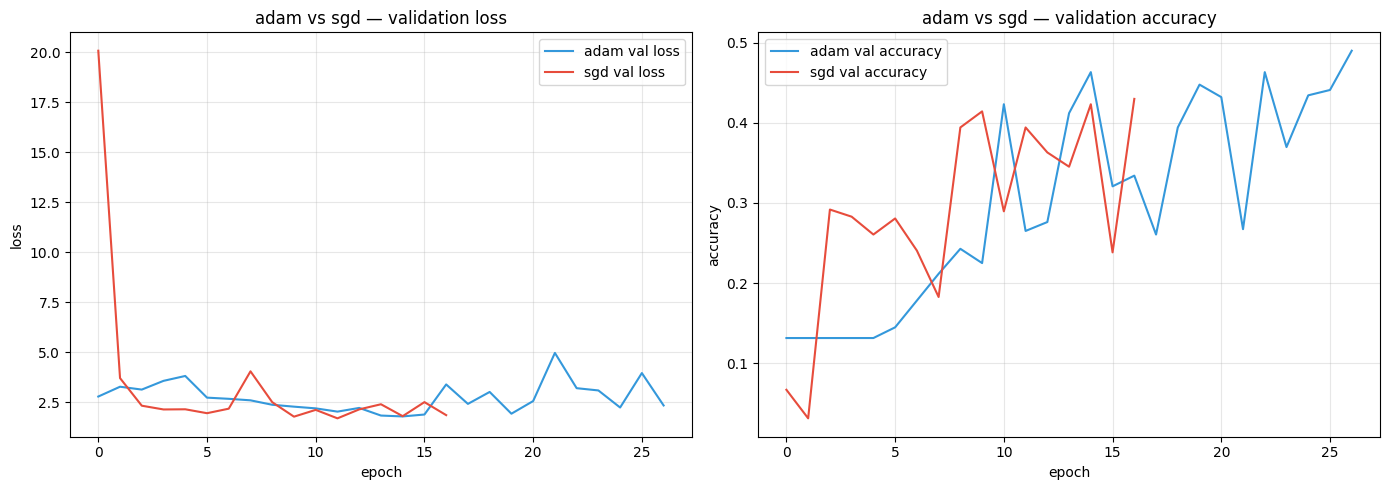

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_loss'], label='adam val loss', color='#3498db')
axes[0].plot(history_sgd.history['val_loss'],    label='sgd val loss',  color='#e74c3c')
axes[0].set_title('adam vs sgd — validation loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['val_accuracy'], label='adam val accuracy', color='#3498db')
axes[1].plot(history_sgd.history['val_accuracy'],    label='sgd val accuracy',  color='#e74c3c')
axes[1].set_title('adam vs sgd — validation accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

# ablation study — remove dropout from deeper model

In [ ]:

deeper_model_no_dropout = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    # dropout removed for ablation study
    layers.Dense(256, activation='relu'),
    # dropout removed for ablation study
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name="deeper_no_dropout")

deeper_model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

start_time = time.time()

history_no_dropout = deeper_model_no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose =1
)

print(f"no dropout training time: {(time.time()-start_time)/60:.2f} minutes")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 207ms/step - accuracy: 0.2979 - loss: 2.2116 - precision: 0.3918 - recall: 0.1687 - val_accuracy: 0.2049 - val_loss: 3.3346 - val_precision: 0.2082 - val_recall: 0.1693
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3782 - loss: 1.8388 - precision: 0.4736 - recall: 0.2233 - val_accuracy: 0.1314 - val_loss: 3.9353 - val_precision: 0.1317 - val_recall: 0.1314
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.4351 - loss: 1.6930 - precision: 0.5419 - recall: 0.2476 - val_accuracy: 0.1314 - val_loss: 4.5732 - val_precision: 0.1347 - val_recall: 0.1314
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.4545 - loss: 1.5109 - precision: 0.5968 - recall: 0.2784 - val_accuracy: 0.1537 - val_loss: 3.2445 - val_precision: 0.1635 - val_recall: 0.1359
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5049 - loss: 1.3627 - precision: 0.6365 - recall: 0.3373 - val_accuracy: 0.2027 - val_loss: 3.0600 - val_pre

# ablation study results

In [ ]:

_, acc_with_dropout,    _, _ = deeper_model.evaluate(test_ds, verbose=0)
_, acc_without_dropout, _, _ = deeper_model_no_dropout.evaluate(test_ds, verbose=0)

print(f"deeper with dropout:    {acc_with_dropout*100:.2f}%")
print(f"deeper without dropout: {acc_without_dropout*100:.2f}%")
print(f"impact of dropout:      {(acc_with_dropout - acc_without_dropout)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


deeper with dropout:    46.69%
deeper without dropout: 37.74%
impact of dropout:      8.95%


# challenges and observations summary

In [ ]:

print("challenges and observations:")
print(f"  baseline training time:      {baseline_training_time/60:.2f} mins")
print(f"  deeper (adam) training time: {deeper_training_time/60:.2f} mins")
print(f"  deeper (sgd) training time:  {sgd_training_time/60:.2f} mins")
print(f"  hardware used: T4 GPU on Google Colab")
print(f"  baseline epochs completed:   {len(history_baseline.history['loss'])}")
print(f"  deeper epochs completed:     {len(history_deeper.history['loss'])}")

challenges and observations:
  baseline training time:      1.21 mins
  deeper (adam) training time: 2.30 mins
  deeper (sgd) training time:  1.64 mins
  hardware used: T4 GPU on Google Colab
  baseline epochs completed:   13
  deeper epochs completed:     27


# Part B: Fine tuining a pre trained model RESNET50

In [ ]:
# Resnet 50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model

# load resnet50 without top classification layer
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

print(f"base model layers: {len(base_model.layers)}")
print(f"trainable layers:  {len([l for l in base_model.layers if l.trainable])}")

base model layers: 175
trainable layers:  0


# build transfer learning model

In [ ]:
#
# from tensorflow.keras import layers, models, Input

# inputs = Input(shape=(224, 224, 3))
# x = base_model(inputs, training=False)
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dense(256, activation='relu')(x)
# x = layers.Dropout(0.3)(x)
# x = layers.Dense(128, activation='relu')(x)
# outputs = layers.Dense(num_classes, activation='softmax')(x)

# transfer_model = Model(inputs, outputs, name="resnet50_transfer")

# transfer_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss='categorical_crossentropy',
#     metrics=['accuracy',
#              tf.keras.metrics.Precision(name='precision'),
#              tf.keras.metrics.Recall(name='recall')]
# )

# transfer_model.summary()
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications.resnet50 import preprocess_input

inputs = Input(shape=(224, 224, 3))

# Convert from [0,1] back to [0,255], then apply ResNet50 ImageNet preprocessing
x = layers.Rescaling(255.0)(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs, outputs, name='resnet50_transfer')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
transfer_model.summary()

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_14[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 128)       │     32,896 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 9)         │      1,161 │ dense_31[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,146,313 (92.11 MB)

 Trainable params: 558,601 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# phase 1 — feature extraction (frozen base)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping
start_time = time.time()
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)]
)

feature_extraction_time = time.time() - start_time
print(f"feature extraction training time: {feature_extraction_time/60:.2f} minutes")

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.3739 - loss: 1.7560 - precision: 0.5714 - recall: 0.1555 - val_accuracy: 0.4343 - val_loss: 1.6103 - val_precision: 0.5628 - val_recall: 0.2695
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5818 - loss: 1.1051 - precision: 0.7292 - recall: 0.3921 - val_accuracy: 0.5100 - val_loss: 1.5340 - val_precision: 0.5893 - val_recall: 0.4187
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.6950 - loss: 0.8478 - precision: 0.7822 - recall: 0.5688 - val_accuracy: 0.5501 - val_loss: 1.5626 - val_precision: 0.6056 - val_recall: 0.4855
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.7439 - loss: 0.7088 - precision: 0.8028 - recall: 0.6541 - val_accuracy: 0.5501 - val_loss: 1.5590 - val_precision: 0.5876 - val_recall: 0.5078
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7952 - loss: 0.5595 - precision: 0.8401 - recall: 0.7285 - val_accuracy: 0.5590 - val_loss: 1.931

# phase 2 — fine-tuning (unfreeze last 30 layers)

In [ ]:

base_model.trainable = True

# freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"trainable layers after unfreezing: {len([l for l in base_model.layers if l.trainable])}")

# recompile with lower learning rate
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

start_time = time.time()

history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                             restore_best_weights=True, verbose=1)]
)

finetuning_time = time.time() - start_time
print(f"fine-tuning training time: {finetuning_time/60:.2f} minutes")

trainable layers after unfreezing: 30
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 334ms/step - accuracy: 0.7024 - loss: 0.9078 - precision: 0.8306 - recall: 0.5632 - val_accuracy: 0.5323 - val_loss: 3.3410 - val_precision: 0.5476 - val_recall: 0.5256
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9059 - loss: 0.3505 - precision: 0.9415 - recall: 0.8619 - val_accuracy: 0.5791 - val_loss: 3.2354 - val_precision: 0.5885 - val_recall: 0.5702
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9501 - loss: 0.2184 - precision: 0.9692 - recall: 0.9321 - val_accuracy: 0.5857 - val_loss: 3.5866 - val_precision: 0.5916 - val_recall: 0.5679
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9729 - loss: 0.1300 - precision: 0.9756 - recall: 0.9673 - val_accuracy: 0.5724 - val_loss: 3.7116 - val_precision: 0.5767 - val_recall: 0.5612
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9783 - loss: 0.0945 - precision: 0.9827 - recall: 0.9726 - 

# plot feature extraction vs fine-tuning curves

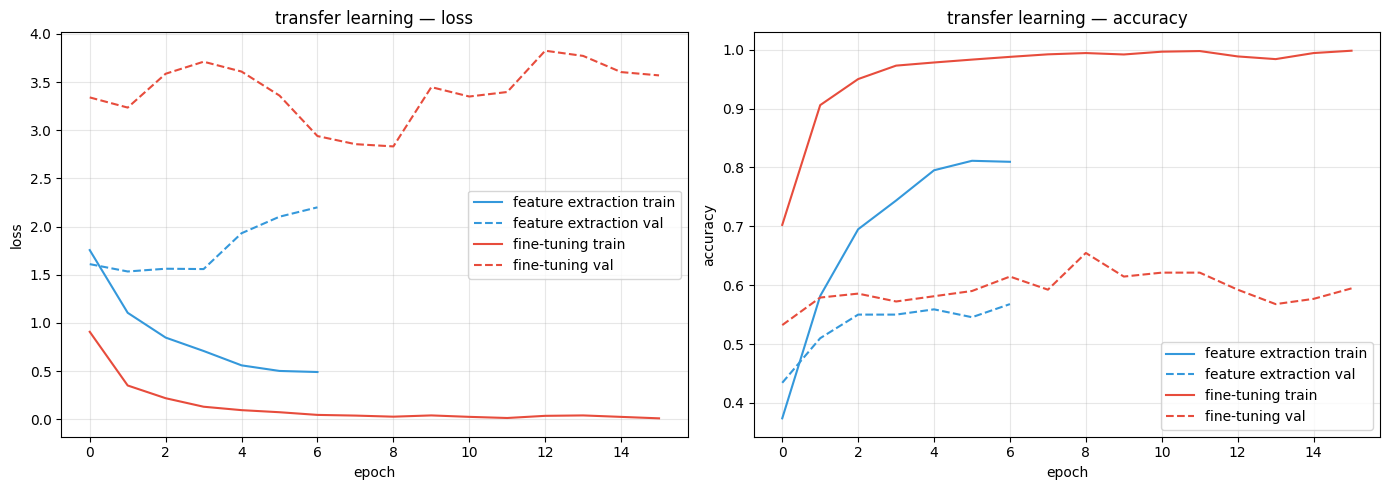

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_transfer.history['loss'],      label='feature extraction train', color='#3498db')
axes[0].plot(history_transfer.history['val_loss'],  label='feature extraction val',   color='#3498db', linestyle='--')
axes[0].plot(history_finetune.history['loss'],      label='fine-tuning train',        color='#e74c3c')
axes[0].plot(history_finetune.history['val_loss'],  label='fine-tuning val',          color='#e74c3c', linestyle='--')
axes[0].set_title('transfer learning — loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_transfer.history['accuracy'],     label='feature extraction train', color='#3498db')
axes[1].plot(history_transfer.history['val_accuracy'], label='feature extraction val',   color='#3498db', linestyle='--')
axes[1].plot(history_finetune.history['accuracy'],     label='fine-tuning train',        color='#e74c3c')
axes[1].plot(history_finetune.history['val_accuracy'], label='fine-tuning val',          color='#e74c3c', linestyle='--')
axes[1].set_title('transfer learning — accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# evaluate transfer model

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 494ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        10
      basal cell carcinoma       0.57      0.77      0.66        35
            dermatofibroma       0.67      0.18      0.29        11
                  melanoma       0.79      0.82      0.80        50
                     nevus       0.65      0.73      0.69        45
pigmented benign keratosis       0.59      0.88      0.71        59
      seborrheic keratosis       0.00      0.00      0.00         7
   squamous cell carcinoma       0.00      0.00      0.00        23
           vascular lesion       1.00      0.88      0.94        17

                  accuracy                           0.66       257
                 macro avg       0.47      0.47      0.45       257
              weighted avg       0.58      0.66      0.60       257



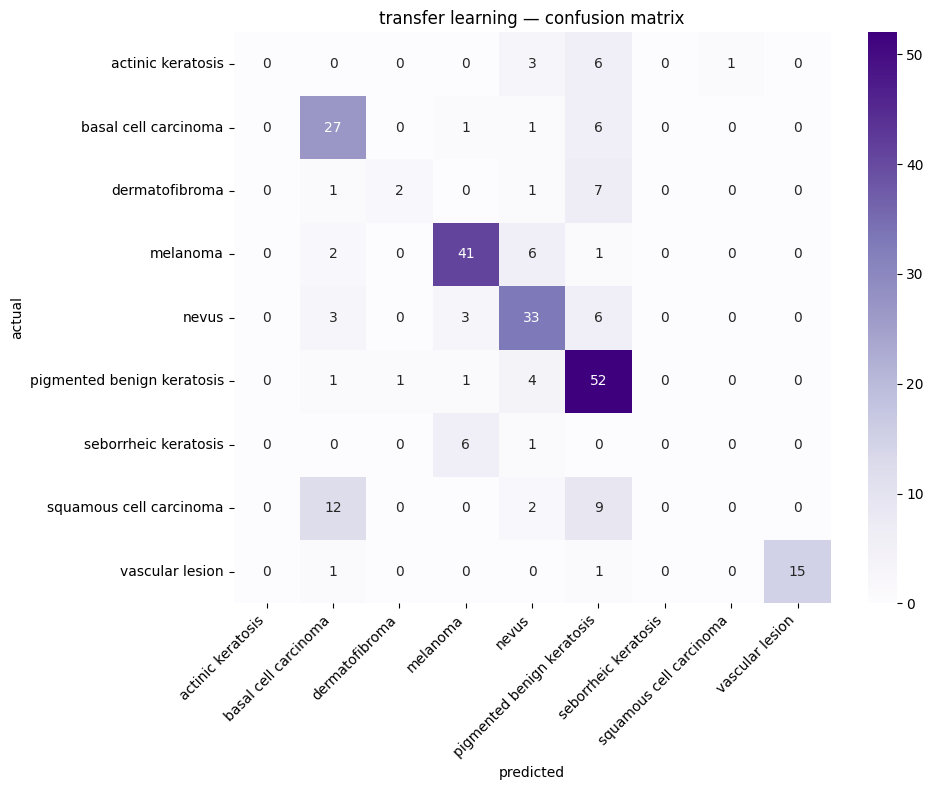

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_transfer = np.argmax(transfer_model.predict(test_ds), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

print(classification_report(y_true, y_pred_transfer, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_transfer)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('transfer learning — confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('transfer_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# inference on sample images — transfer model

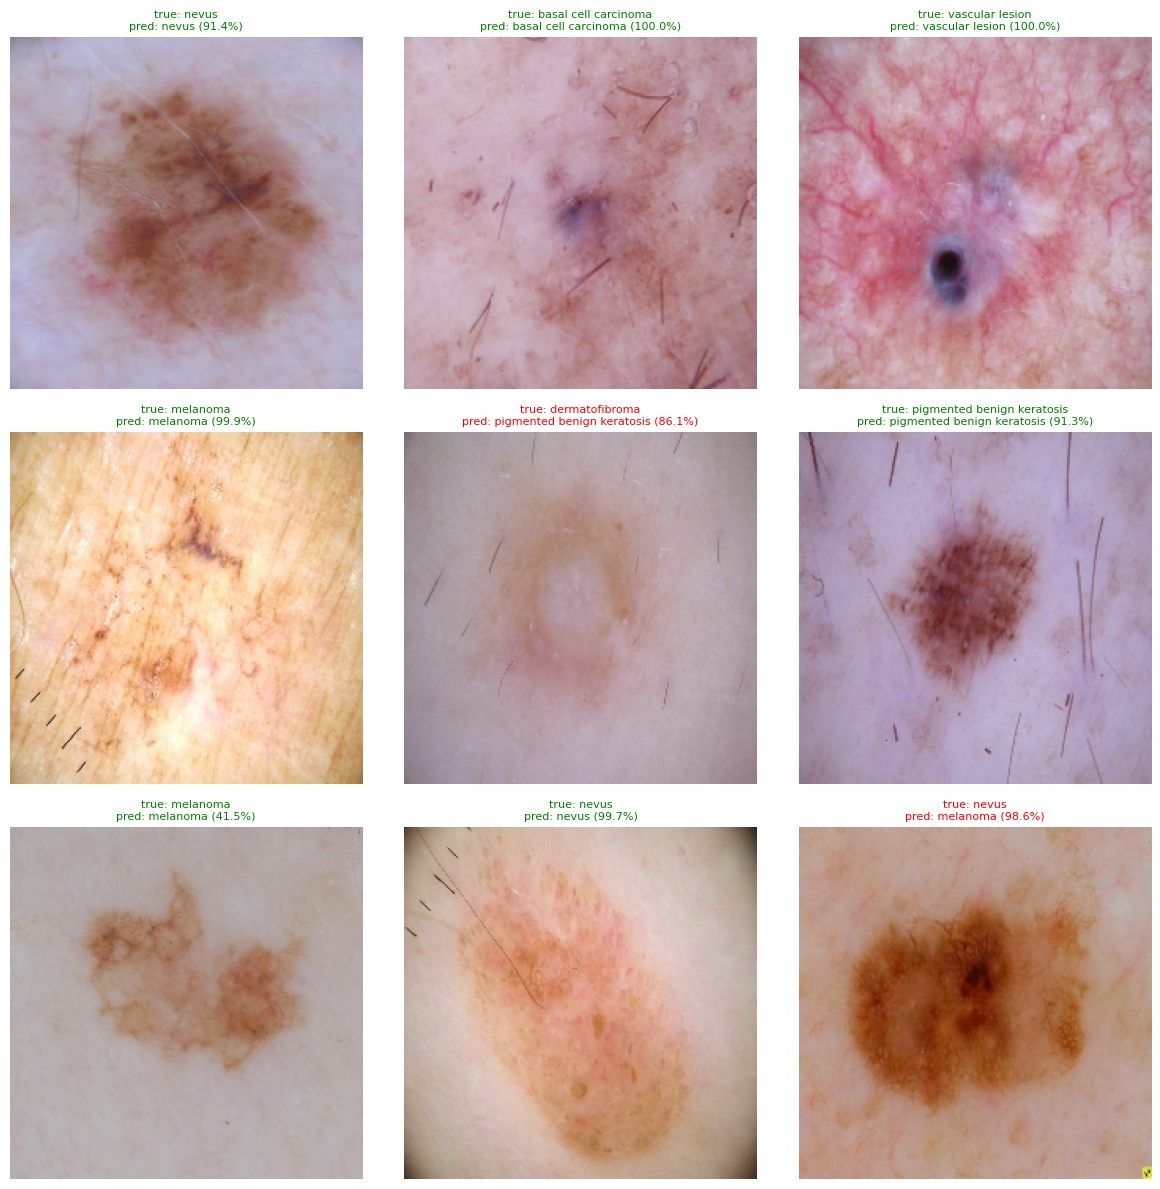

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

sample_images, sample_labels = next(iter(test_ds))
sample_np   = sample_images.numpy()
true_labels = np.argmax(sample_labels.numpy(), axis=1)
predictions = transfer_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

for i, ax in enumerate(axes.flat):
    img        = (sample_np[i] * 255).astype("uint8")
    true_name  = class_names[true_labels[i]]
    pred_name  = class_names[pred_labels[i]]
    confidence = predictions[i][pred_labels[i]] * 100
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"true: {true_name}\npred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color='green' if true_name == pred_name else 'red'
    )
plt.tight_layout()
plt.savefig('transfer_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# final comparison — all three models

In [ ]:

# test_loss_b, test_acc_b, test_prec_b, test_rec_b = baseline_model.evaluate(test_ds, verbose=0)
# test_loss_d, test_acc_d, test_prec_d, test_rec_d = deeper_model.evaluate(test_ds, verbose=0)
# test_loss_t, test_acc_t, test_prec_t, test_rec_t = transfer_model.evaluate(test_ds, verbose=0)

# f1_b = 2 * (test_prec_b * test_rec_b) / (test_prec_b + test_rec_b + 1e-7)
# f1_d = 2 * (test_prec_d * test_rec_d) / (test_prec_d + test_rec_d + 1e-7)
# f1_t = 2 * (test_prec_t * test_rec_t) / (test_prec_t + test_rec_t + 1e-7)

# comparison_df = pd.DataFrame({
#     'metric':   ['accuracy', 'precision', 'recall', 'f1 score'],
#     'baseline': [f"{test_acc_b:.4f}", f"{test_prec_b:.4f}", f"{test_rec_b:.4f}", f"{f1_b:.4f}"],
#     'deeper':   [f"{test_acc_d:.4f}", f"{test_prec_d:.4f}", f"{test_rec_d:.4f}", f"{f1_d:.4f}"],
#     'transfer': [f"{test_acc_t:.4f}", f"{test_prec_t:.4f}", f"{test_rec_t:.4f}", f"{f1_t:.4f}"]
# })

# print(comparison_df.to_string(index=False))



# Final comparison — all three models (sklearn weighted averages)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions from each model
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)
y_pred_d = np.argmax(deeper_model.predict(test_ds, verbose=0), axis=1)
y_pred_t = np.argmax(transfer_model.predict(test_ds, verbose=0), axis=1)
y_true   = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

def get_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred,   average='weighted', zero_division=0),
        'f1 score' : f1_score(y_true, y_pred,       average='weighted', zero_division=0)
    }

m_b = get_metrics(y_true, y_pred_b)
m_d = get_metrics(y_true, y_pred_d)
m_t = get_metrics(y_true, y_pred_t)

comparison_df = pd.DataFrame({
    'metric'  : list(m_b.keys()),
    'baseline': [f"{v:.4f}" for v in m_b.values()],
    'deeper'  : [f"{v:.4f}" for v in m_d.values()],
    'transfer': [f"{v:.4f}" for v in m_t.values()]
})

print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


   metric baseline deeper transfer
 accuracy   0.4319 0.4669   0.6615
precision   0.5085 0.4662   0.5753
   recall   0.4319 0.4669   0.6615
 f1 score   0.4186 0.4363   0.6031
